<a href="https://colab.research.google.com/github/gerardkutsukawa/data-analytics-portfolio/blob/main/Finals_Diabetes_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Final Project: Diabetes Dataset

The aim of this analysis is to investigate a range of health-related factors and their interconnections to classify diabetes accurately. These factors include aspects such as age, gender, body mass index (BMI), hypertension, heart disease, smoking history, HbA1c level, and blood glucose level.

These data, when combined and analyzed with appropriate statistical and machine learning techniques, can help in predicting an individual's risk of developing diabetes.

### Packages

In [ ]:
#### Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

### Data

In [ ]:
pdf = pd.read_csv('/content/drive/MyDrive/Kutsukawa_Churn/data/diabetes_prediction_dataset.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#### Basic information
pdf.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
#### Shape
pdf.shape

(100000, 9)

Before we remove the duplicated data the total amount of shape is (100,000).

In [ ]:
#### Null
pdf.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
pdf = pdf.drop_duplicates()

I used this method to remove the duplicated data (3854).

In [ ]:
### Duplicate
pdf.duplicated().sum()

np.int64(0)

In [ ]:
# Remove Unneccessary value [0.00195%]
pdf = pdf[pdf['gender'] != 'Other']

In [ ]:
#### First 5 rows
pdf.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
pdf.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000
mean,41.796617,0.077615,0.040810,27.321450,5.532633,138.218001,0.088237
std,22.463329,0.267567,0.197851,6.767811,1.073225,40.911190,0.283640
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


# <span style="color:#E888BB; font-size: 1%;">EXPLORATORY DATA ANALYSIS</span>


## <div style="padding: 20px;color:white;margin:10;font-size:90%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-image: url(https://w0.peakpx.com/wallpaper/957/661/HD-wallpaper-white-marble-white-stone-texture-marble-stone-background-white-stone.jpg)"><b><span style='color:black'> Univariate Analysis</span></b> </div>


### <b>I <span style='color:#16C2D5'>|</span> Age</b>

<Axes: ylabel='Frequency'>

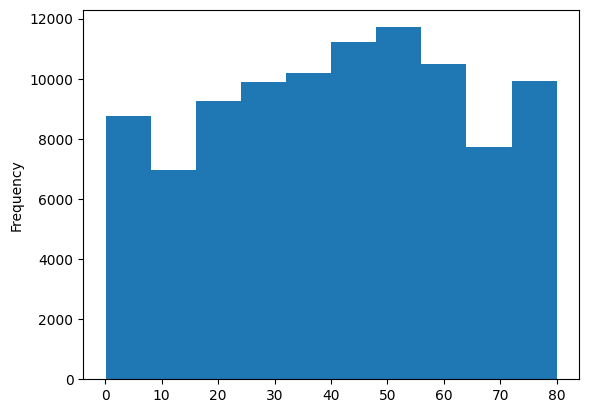

In [ ]:
# Histogram for age
pdf['age'].plot(kind='hist')

The distribution of age is right-skewed, meaning there are more younger people than older people in the dataset.

The mean age is 41.8 years old.

The standard deviation is 22.5 years old, which is a large spread relative to the mean. This indicates that there is a significant variation in ages in the dataset.

There are a few people in the dataset who are younger than 24 years old and a few who are older than 80 years old.

<Axes: >

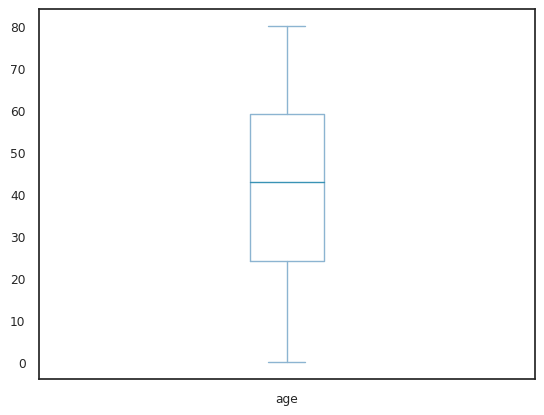

In [ ]:
# Boxplot for age
pdf['age'].plot(kind='box')

The median age is 43 years old. This is different from the mean (41.8 years old), which tells us that the distribution is not symmetrical.

The interquartile range (IQR) is 35 years old (from 24 to 59 years old). This means that the middle 50% of the data falls within this range.

The majority of the people in the dataset are between 24 and 59 years old.
There is a significant variation in ages in the dataset.



### <b>II <span style='color:#16C2D5'>|</span> Gender</b>

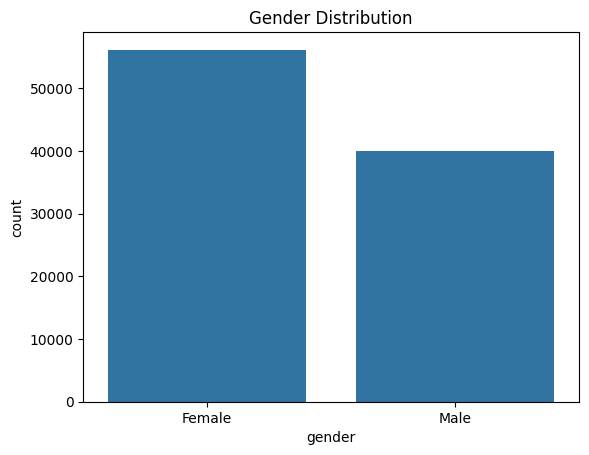

In [ ]:
# Bar plot for gender
sns.countplot(x='gender', data=pdf)
plt.title('Gender Distribution')
plt.show()



There are significantly more females than males in the dataset.

The gender distribution is unbalanced. This could be a cause for concern if you are trying to draw conclusions about a population from this data set, for example, if you are trying to understand user preferences where a balanced representation of genders is important.


### <b>III <span style='color:#16C2D5'> | </span>BMI</b>

<Axes: ylabel='Frequency'>

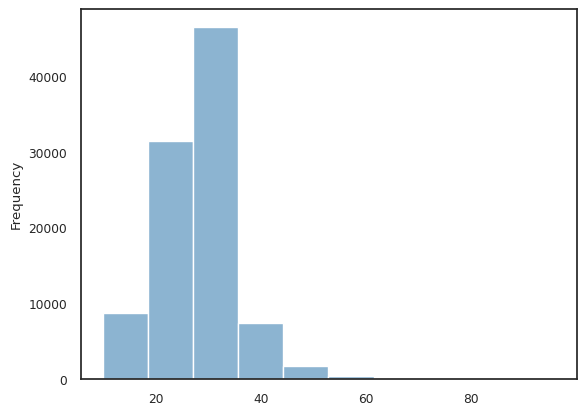

In [ ]:
# Histogram for BMI
pdf['bmi'].plot(kind='hist')

 This means there are more people with a BMI in the normal weight range (18.5 to 24.9) than there are people who are overweight or obese (over 25). However, a significant number of people fall into the overweight or obese categories.

 The mean BMI is 27.32, which is slightly above the normal weight range.

The standard deviation is 6.77, which indicates a moderate spread of BMI values around the mean.

This data suggests a population with a higher than normal prevalence of overweight and obesity.

<Axes: >

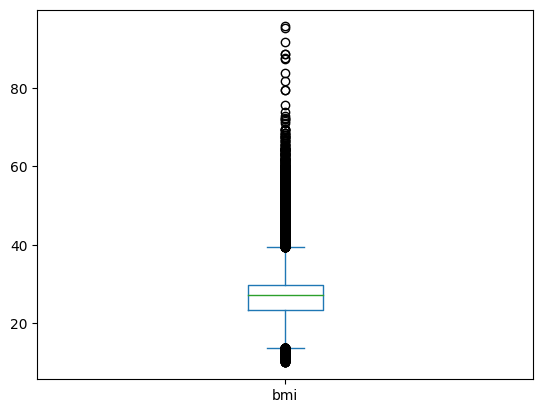

In [ ]:
# Boxplot for BMI
pdf['bmi'].plot(kind='box')

The interquartile range (IQR) is 6.46 (from 23.4 to 29.86). This means that the middle 50% of the data falls within this range, with a higher concentration towards the lower end.

There are more people with a BMI in the normal weight range (18.5 to 24.9) than there are people who are overweight or obese (over 25). However, the box plot also highlights a significant number of people in the overweight and obese categories.

There are outliers on both ends of the distribution, with a few data points below 23.4 and above 29.86.

This data suggests a population with a higher than normal prevalence of overweight and obesity, similar to what we observed in the histogram.

### <b><span style='color:#16C2D5'></span> Count plots for binary


<Axes: xlabel='hypertension'>

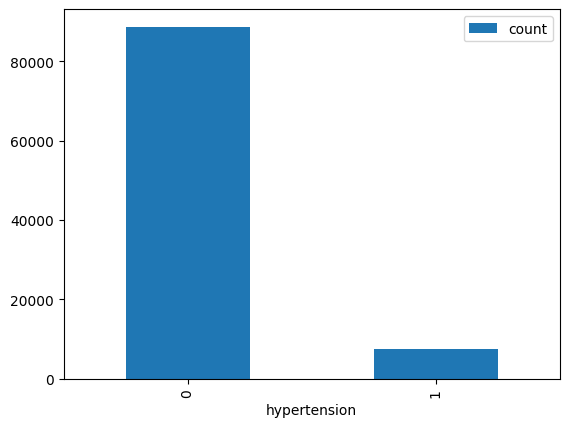

In [ ]:
pdf['hypertension'].value_counts().plot(kind='bar', legend=True)

<Axes: xlabel='heart_disease'>

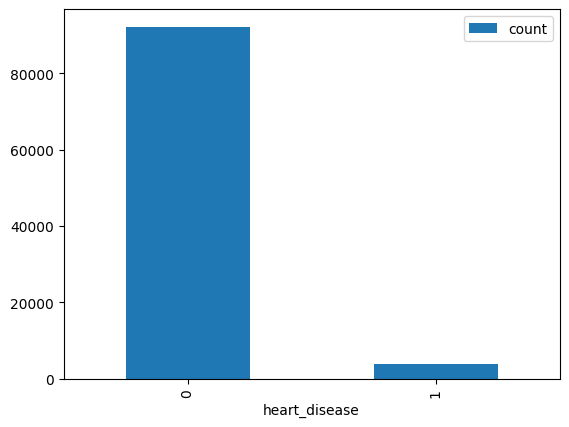

In [ ]:
pdf['heart_disease'].value_counts().plot(kind='bar', legend=True)

<Axes: xlabel='diabetes'>

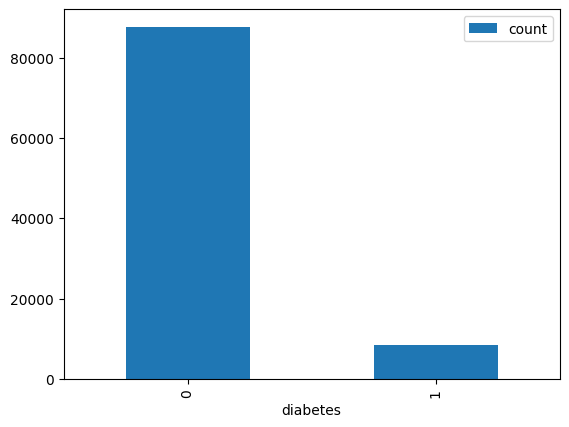

In [ ]:
pdf['diabetes'].value_counts().plot(kind='bar', legend=True)

### <b><span style='color:#16C2D5'></span> Count plot for smoking history</b>

<Axes: xlabel='smoking_history'>

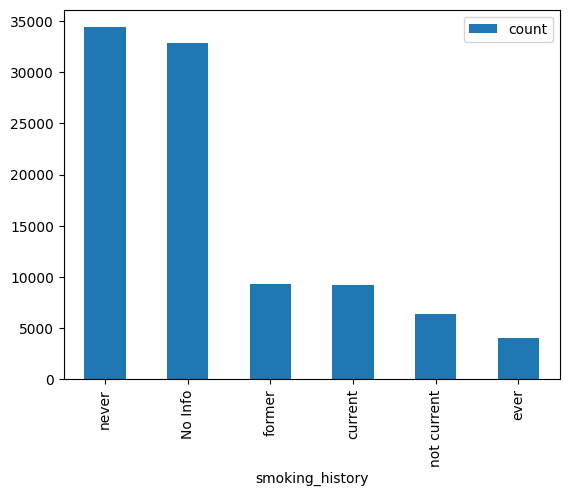

In [ ]:
# Count plot for smoking history
pdf['smoking_history'].value_counts().plot(kind='bar', legend=True)

The smoking history category with the most people is "never smoked" in all the categories shown. This suggests that a majority of the population in these countries has never smoked.

There are still significant numbers of people in the categories "former smoker," "current smoker," and "not current smoker." This suggests that smoking is still present among the population represented in the data.

Even without knowing the specific countries, the data highlights that smoking is a behavior with varying prevalence across different groups of people.

## <div style="padding: 20px;color:white;margin:10;font-size:90%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-image: url(https://w0.peakpx.com/wallpaper/957/661/HD-wallpaper-white-marble-white-stone-texture-marble-stone-background-white-stone.jpg)"><b><span style='color:black'>Bivariative Analysis</span></b> </div>
### <b><span style='color:#16C2D5'></span> Boxplot BMI vs Diabetes classification</b>

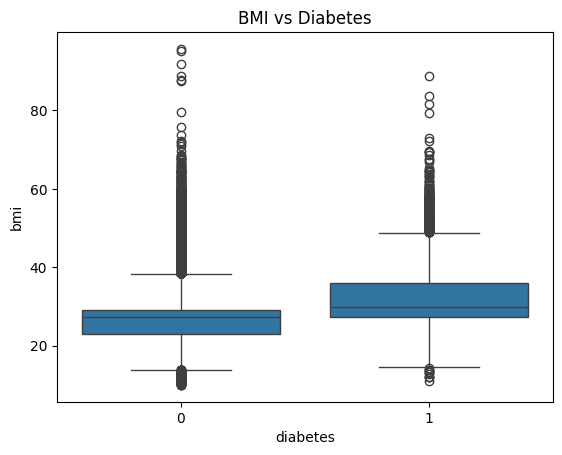

In [ ]:
# Boxplot BMI vs Diabetes classification
sns.boxplot(x='diabetes', y='bmi', data=pdf)
plt.title('BMI vs Diabetes')
plt.show()

The boxplot shows a positive correlation between BMI and diabetes. The median BMI for people with diabetes (1) is higher than the median BMI for people without diabetes (0). This means that people with diabetes in this dataset tend to have a higher BMI than people without diabetes.

The interquartile range (IQR) for BMI is larger for people with diabetes compared to people without diabetes. This suggests a greater spread of BMI values among people with diabetes. There are outliers on both ends of the distribution for the diabetic group, with some people with a BMI below 23.4 and others with a BMI above 29.86.



The data suggests that BMI may be a risk factor for diabetes in this population. People with a higher BMI are more likely to have diabetes.

### <b><span style='color:#16C2D5'></span> Boxplot Age vs Diabetes classification</b>

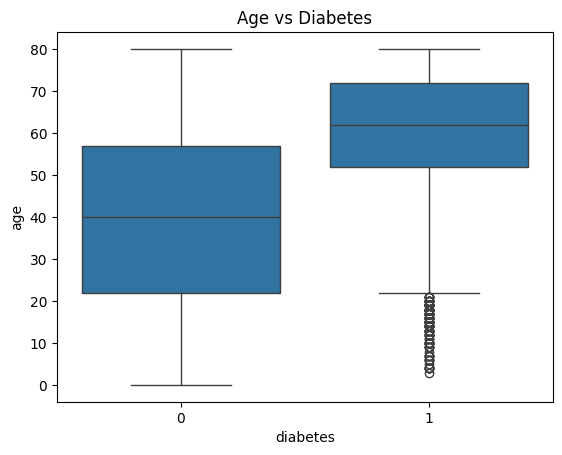

In [ ]:
# Boxplot Age vs Diabetes classification
sns.boxplot(x='diabetes', y='age', data=pdf)
plt.title('Age vs Diabetes')
plt.show()

The box plot shows a positive correlation between age and diabetes. The median age for people with diabetes (1) is higher than the median age for people without diabetes (0). This means that people with diabetes in this dataset tend to be older than people without diabetes.

The interquartile range (IQR) for age is similar for both diabetic and non-diabetic groups. This suggests that the age distribution is comparable across the two groups.


The data suggests that age may be a risk factor for diabetes in this population. People who are older are more likely to have diabetes.

### <b><span style='color:#16C2D5'></span> Count plot of gender vs diabetes</b>

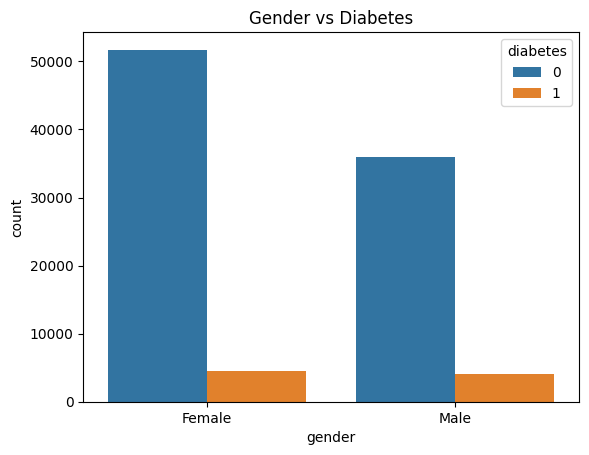

In [ ]:
# Count plot of gender vs diabetes
sns.countplot(x='gender', hue='diabetes', data=pdf)
plt.title('Gender vs Diabetes')
plt.show()

There are significantly more people without diabetes (0) than with diabetes (1) in the dataset. The vast majority of people (around 91%) fall into the non-diabetic category.

The prevalence of diabetes in this dataset appears to be lower than what might be expected in a typical population. It's important to consider that this may not be representative of the general population, depending on how the data was collected.



###<b><span style='color:#16C2D5'></span> Boxplot HbA1c level vs Diabetes classification</b>

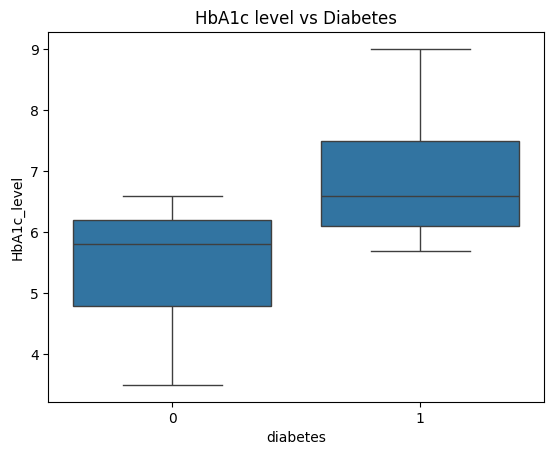

In [ ]:
# Boxplot HbA1c level vs Diabetes classification
sns.boxplot(x='diabetes', y='HbA1c_level', data=pdf)
plt.title('HbA1c level vs Diabetes')
plt.show()

The boxplot shows that the distribution of HbA1c levels is different for people with diabetes (1) compared to people without diabetes (0). The median HbA1c level is significantly higher for people with diabetes (around 6.2) compared to people without diabetes (around 5.8). This suggests that people with diabetes in this dataset tend to have higher HbA1c levels than people without diabetes.

There's also more spread in the HbA1c levels for the diabetic group compared to the non-diabetic group, as indicated by the larger interquartile range (IQR) for the diabetic group.

The data confirms a positive correlation between HbA1c level and diabetes. People with diabetes are more likely to have higher HbA1c levels, which is consistent with how HbA1c is used to diagnose and monitor diabetes.

### <b><span style='color:#16C2D5'></span> Boxplot blood glucose level vs Diabetes classification</b>




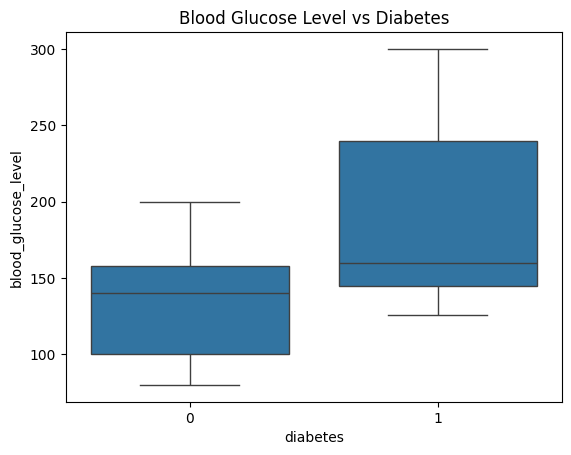

In [ ]:
# Boxplot blood glucose level vs Diabetes classification
sns.boxplot(x='diabetes', y='blood_glucose_level', data=pdf)
plt.title('Blood Glucose Level vs Diabetes')
plt.show()

The blood glucose levels are significantly higher for people with diabetes (median around 159) compared to people without diabetes (median around 140). This positive correlation between blood glucose level and diabetes is expected because diabetes is a condition marked by elevated blood sugar levels.

The spread of blood glucose levels is larger for the diabetic group (IQR=59) compared to the non-diabetic group (IQR=40), indicated by the larger interquartile range (IQR) for the diabetic group. There are also outliers on both ends of the distribution for the diabetic group.

The data confirms a positive correlation between blood glucose level and diabetes, supporting the role of blood glucose level in diagnosing or monitoring diabetes.

### <b><span style='color:#16C2D5'></span> Correlation Matrix</b>

In [ ]:
# Define a function to map the existing categories to new ones
def recategorize_smoking(smoking_status):
    if smoking_status in ['never', 'No Info']:
        return 'non-smoker'
    elif smoking_status == 'current':
        return 'current'
    elif smoking_status in ['ever', 'former', 'not current']:
        return 'past_smoker'

# Apply the function to the 'smoking_history' column
pdf['smoking_history'] = pdf['smoking_history'].apply(recategorize_smoking)

# Check the new value counts
print(pdf['smoking_history'].value_counts())

smoking_history
non-smoker     67276
past_smoker    19655
current         9197
Name: count, dtype: int64


In [ ]:
data = pdf.copy()

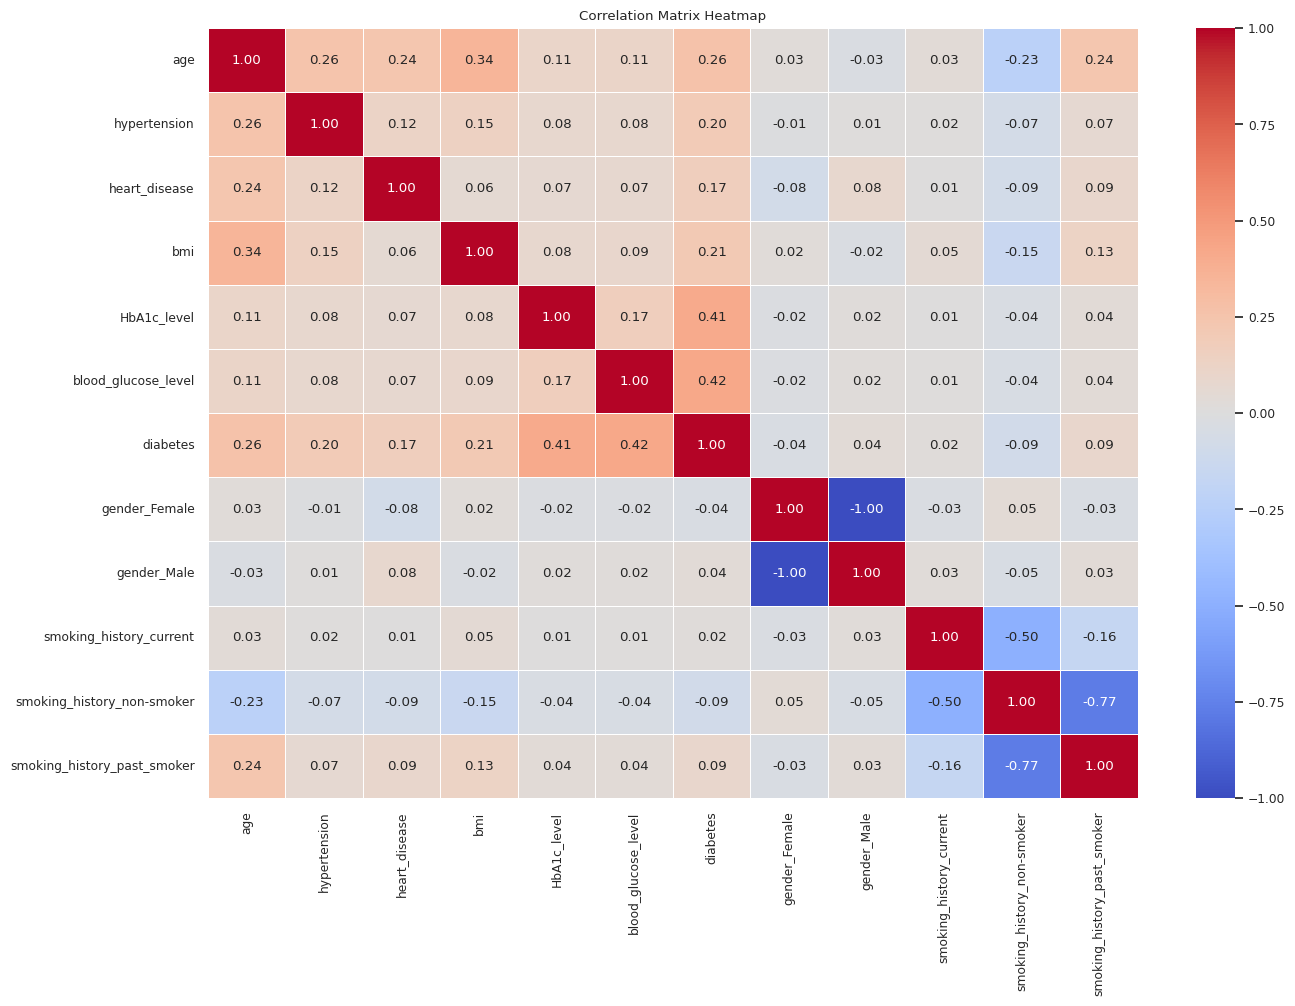

In [ ]:
# Compute the correlation matrix
correlation_matrix = data.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()



There are positive correlations between several pairs of variables. For instance, there appears to be a moderate positive correlation between age and blood pressure (hypertension). This means that as age increases, blood pressure also tends to increase.

Similarly, there appears to be a positive correlation between BMI and blood glucose levels. This suggests that people with a higher BMI tend to have higher blood sugar levels.

Other interesting correlations can be observed between diabetes and other health factors. There appears to be a positive correlation between diabetes and hypertension (blood pressure) and HbA1c levels. This is consistent with how these measures are used to diagnose and monitor diabetes.


The data suggests potential links between various health conditions. People with diabetes may be more likely to have high blood pressure and higher HbA1c levels. Additionally, people with a higher BMI may be more likely to have higher blood sugar levels.

## Data Preparation

In [ ]:
data = pdf.copy()

In [ ]:
# Separate target variable and features
y = data['diabetes']
X = data.drop(['diabetes'], axis=1)

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modeling

In [ ]:
# Model
estimator = LogisticRegression()

# Create transformers for categorical and numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore'), ['gender','smoking_history'])
        ,('num_standard', StandardScaler(), ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level','hypertension','heart_disease'])
    ],
    remainder='passthrough',
)

# Create a logistic regression model using a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
    ,('estimator', estimator)
])

# Fit training data into model pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'smoking_history']),
                                                 ('num_standard',
                                                  StandardScaler(),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level',
                                                   'hypertension',
                                                   'heart_disease'])])),
                ('estimator', LogisticRegression())])

StandardScaler for numeric features like age, BMI, and other health-related metrics is a common choice in machine learning pipelines.

StandardScaler in this context is to standardize the features by removing the mean and scaling them to unit variance. This process helps in achieving better performance and stability in many machine learning algorithms, including logistic regression.

## Evaluation

Accuracy: 0.96
Precision: 0.87
Recall: 0.63

Confusion Matrix:
[[69474   647]
 [ 2504  4277]]


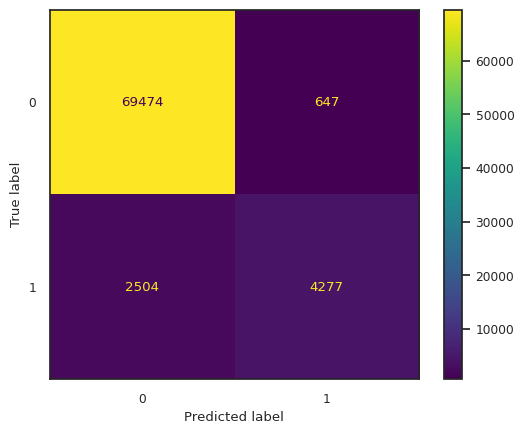

In [ ]:
# Make predictions on the train set
y_pred_train = pipeline.predict(X_train)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print(f"Accuracy: {accuracy_train:.2f}")
print(f"Precision: {precision_train:.2f}")
print(f"Recall: {recall_train:.2f}")
print(f"\nConfusion Matrix:")
print(cm_train)

cmd_train = ConfusionMatrixDisplay(cm_train)
cmd_train.plot()

Accuracy: 0.96
Precision: 0.86
Recall: 0.62

Confusion Matrix:
[[17355   170]
 [  649  1052]]


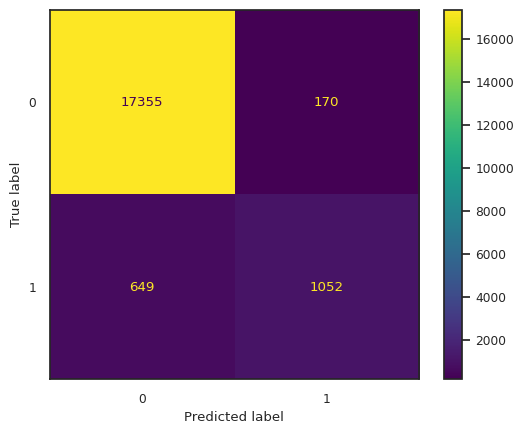

In [ ]:
# Make predictions on the test set
y_pred_test = pipeline.predict(X_test)

# Evaluate the model
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
cm_test = confusion_matrix(y_test, y_pred_test)

print(f"Accuracy: {accuracy_test:.2f}")
print(f"Precision: {precision_test:.2f}")
print(f"Recall: {recall_test:.2f}")
print(f"\nConfusion Matrix:")
print(cm_test)

cmd_test = ConfusionMatrixDisplay(cm_test)
cmd_test.plot()

Accuracy: The prediction model is good because it can correctly predic 96% of the time of Diabetes outcomes.

Precision: The precision is 86% correct when when a patient or a person has a Diabetes.

Recall: It can capture 62% actual cases of diabetes

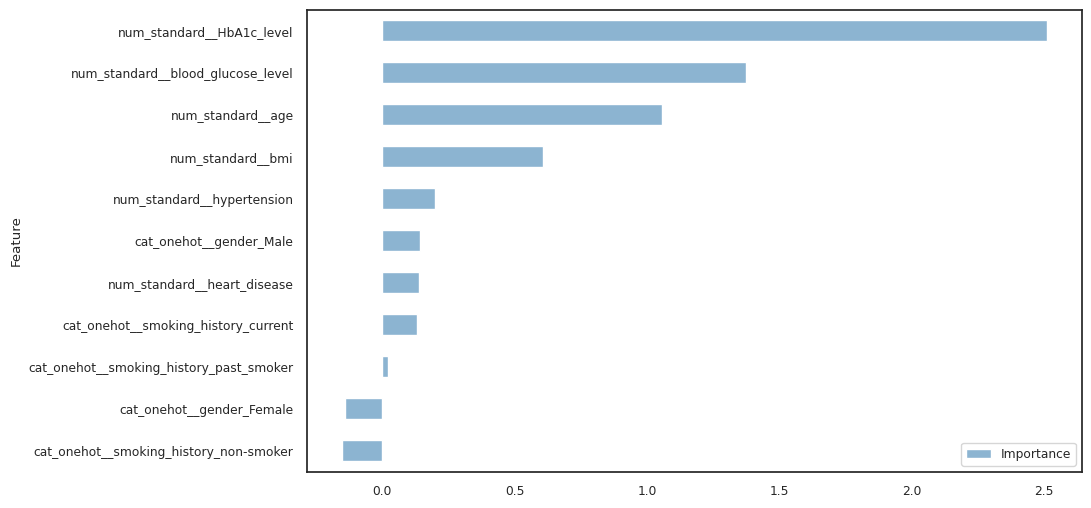

Intercept: -5.112746282994012


In [ ]:
#### Get coefficients & intercept

coefficients = pipeline.named_steps.estimator.coef_[0]
feature_names = pipeline.named_steps.preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))
plt.show()

intercept = pipeline.named_steps.estimator.intercept_[0]
print(f'Intercept: {intercept}')